#### Time Series - Stochastic Processes

Review stochastic processes, and define the power spectra of their autocorrelation functions.

Introduce stationary processes and general framework to study stationary time series.
- Recall a stochastic process is a collection of random variables with a joint-distribution.
- Compute the first and second order statistics of a stochastic process i.e. the mean and autocovariance functions
- Define and verify wide-sense (or weak) stationarity of stochastic processes.
- Define the power spectrum as the Fourier transform of the autocorrelation function and compute it.

Describe a general framework for studying wide-sense stationary processes as filtered
white noise processes.

##### Stochastic Processes

A **stochastic process** is a sequence of random variables, $X(-t)$, ..., $X(0)$, ..., $X(1)$, ..., $X(t)$, with a joint probability distribution.
A time series is modeled as a single realization of a stochastic process.
For a particular sequence of rv.s ${X(t)}_{t \in \mathbb{Z}}$, use the Mean and Autocovariance features to characterize the stochastic process:
- **Mean** $\mu(t) = E[X(t)]$, is the expectation of each variable of the sequence and is a function of time, i.e., a trajectory.
- **Autocovariance**
$\rho(t_1, t_2) = \text{Cov}(X(t_1), X(t_2)) = E[(X(t_1) - \mu(t_1))(X(t_2) - \mu(t_2))] = R(t_1,t_2) - \mu(t_1)\mu(t_2)$,
where $R(t_1,t_2)$ is called the **autocorrelation function**.
The autocovariance $\rho(t_1,t_2)$ is a function of two particular time steps. It is important to make assumptions on the structure of the autocovariance.

- **Variance** $\text{Var}(X(t)) = \rho(t,t) = R(t,t) - \mu(t)^2$. The variance is also a function of time.

##### Wide Sense Stationarity (WSS)

A time series is said to be Wide Sense Stationary (also known as covariance stationary) if its statistical properties, specifically its mean and autocorrelation, do not change over time. This makes WSS processes easier to analyze and model compared to non-stationary processes.
A random process $X(t)$ is Wide Sense Stationary if it satisfies the following two conditions:

1.  **Constant Mean**, the mean of the process is constant over time, $E[X(t)] = \mu$ for all $t$.

2.  **Autocorrelation** depends only on the time difference (lag) $\tau$, not on the absolute time $t$, $R_X(t, t+\tau) = E[X(t)X(t+\tau)] = R_X(\tau)$ for all $t$ and $\tau$.

From these two conditions, it follows that the **variance** of a WSS process is constant over time, as variance is a special case of autocorrelation where $\tau = 0$: $Var[X(t)] = E[X(t)^2] - (E[X(t)])^2 = R_X(0) - \mu^2 = \sigma^2$. Since $R_X(0)$ is a constant and $\mu$ is a constant, the variance $\sigma^2$ must also be a constant.

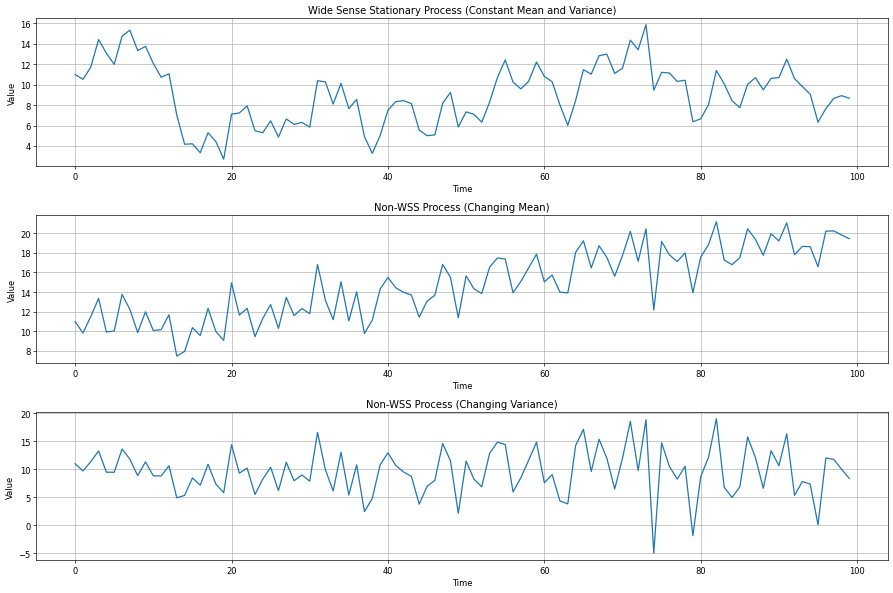

In [ ]:
# Function to generate a WSS process
def generate_wss_process(num_samples, mean, std_dev, correlation_strength=0.8):
    # Simulate a WSS process with constant mean and variance
    # Using an AR(1) process for simplicity to show constant autocorrelation
    np.random.seed(42)
    errors = np.random.normal(0, std_dev, num_samples)
    process = np.zeros(num_samples)
    process[0] = mean + errors[0]
    for i in range(1, num_samples):
        process[i] = mean + correlation_strength * (process[i-1] - mean) + errors[i]
    return process

# Function to generate a non-WSS process (changing mean)
def generate_non_wss_mean(num_samples, initial_mean, std_dev):
    np.random.seed(42)
    t = np.arange(num_samples)
    # Mean changes linearly over time
    varying_mean = initial_mean + 0.1 * t
    process = varying_mean + np.random.normal(0, std_dev, num_samples)
    return process

# Function to generate a non-WSS process (changing variance)
def generate_non_wss_variance(num_samples, mean, initial_std_dev):
    np.random.seed(42)
    t = np.arange(num_samples)
    # Standard deviation changes linearly over time
    varying_std_dev = initial_std_dev + 0.05 * t
    process = mean + np.random.normal(0, varying_std_dev, num_samples)
    return process

# Parameters
num_samples, mean_val, std_dev_val = 100, 10, 2

# Generate processes
wss_data = generate_wss_process(num_samples, mean_val, std_dev_val)
non_wss_mean_data = generate_non_wss_mean(num_samples, mean_val, std_dev_val)
non_wss_variance_data = generate_non_wss_variance(num_samples, mean_val, std_dev_val)

The plots above demonstrate the concept of Wide Sense Stationarity:

*   WSS Process: Data fluctuates around a relatively constant mean, and the spread (variance) of the data also appears consistent across the time series. This process was generated with a constant mean and a stable autocorrelation structure, implemented using an AR(1) model.

*   Non-WSS Process (changing mean): Mean of the process clearly increases over time, violating the constant mean condition of WSS. This type of non-stationarity is often observed in trends.

*   Non-WSS Process (changing variance): Spread of the data (variance) visibly increases over time, violating constant variance condition (which is a consequence of constant autocorrelation with lag 0). This indicates a change in the volatility or uncertainty of the process over time.

##### Strong Stationarity (or Strict Stationarity)

A time series is said to be strongly stationary (or strictly stationary) if its joint probability distribution remains unchanged under time shifts. This means that for any set of time points $t_1, t_2, \dots, t_k$, and any time lag $\tau$, the joint probability distribution of $(X(t_1), X(t_2), \dots, X(t_k))$ is the same as the joint probability distribution of $(X(t_1+\tau), X(t_2+\tau), \dots, X(t_k+\tau))$.

**Key implications of Strong Stationarity**:

*   Constant Mean: $E[X(t)] = \mu$ for all $t$.
*   Constant Variance: $Var[X(t)] = \sigma^2$ for all $t$.
*   Autocorrelation function depends only on lag, the time difference, $R_X(t, t+\tau) = R_X(\tau)$.
*   All higher-order moments are constant, including skewness, and any other statistical property derived from the joint distribution.

Strong stationarity is a very strict condition and is rarely encountered in practice. However, it's often assumed for mathematical tractability. If a process is strongly stationary, it is also wide sense stationary, but the converse is not always true (unless the process is Gaussian, in which case WSS implies strong stationarity).

##### Quasi Stationarity

Generally, it refers to processes that exhibit stationary-like behavior for certain periods or under specific conditions, but might not be strictly stationary.

In essence, quasi-stationarity describes a process that has some characteristics of stationarity but does not meet the strict mathematical definitions of either strong or wide sense stationarity, usually implying a weaker or conditional form of stationarity.

Some common interpretations or scenarios where quasi-stationarity might be used

1.  **Locally Stationary** processes with statistical properties that change slowly over time, appearing stationary within shorter observation windows, but are non-stationary globally.

2.  **Stationary** for practical processes might be technically non-stationary (e.g., due to very slow trends or subtle changes in variance), but these deviations from stationarity are negligible or ignorable for the specific analysis or modeling task at hand. In such cases, it's treated as quasi-stationary or approximately stationary.

3.  **Cyclic or Periodically Stationary** processes might exhibit stationary behavior within specific cycles or periods, but their properties change from one cycle to another or are periodic rather than constant. For example, a process might be stationary within a day, but its daily characteristics change seasonally.

4.  **Processes with Transient States** might be non-stationary as it transitions between different stationary states. Once it settles into a particular state, it behaves in a stationary manner for some time. The entire process, including transitions, might be called quasi-stationary.


First 10 values of White Noise:
[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
  1.57921282  0.76743473 -0.46947439  0.54256004]

First 10 values of AR(1) Process:
[0.17889368 0.90561784 1.67545811 2.1997217  1.35097051 0.97676684
 1.44125442 1.76577107 1.99356359 3.82186026]


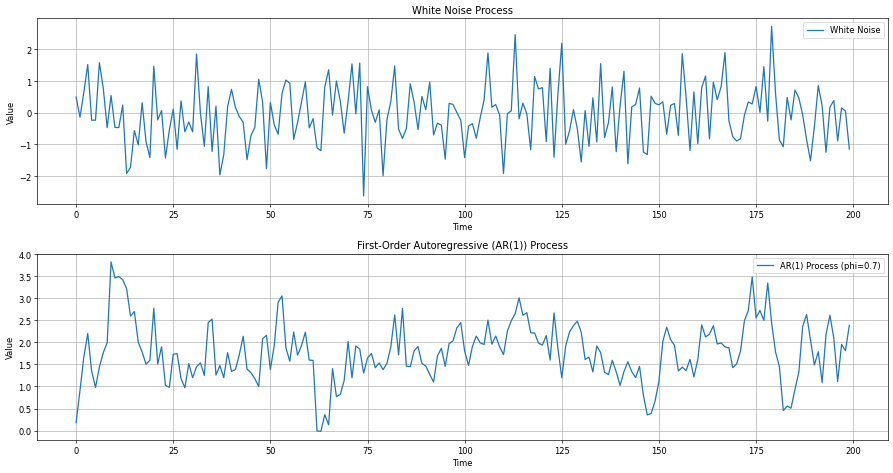

In [ ]:
# Parameters
num_samples = 200

# Generate White Noise
# White noise: i.i.d. normal distribution with mean 0 and std_dev 1
np.random.seed(42)
white_noise = np.random.normal(0, 1, num_samples)
print("\nFirst 10 values of White Noise:")
print(white_noise[:10])

# Generate AR(1) Process
# AR(1) process: X_t = c + phi * X_{t-1} + epsilon_t
c = 0.5        # Constant
phi = 0.7      # Autoregressive parameter (0.7 for moderate positive correlation)
epsilon = np.random.normal(0, 0.5, num_samples) # White noise for the AR(1) process

ar1_process = np.zeros(num_samples)
ar1_process[0] = epsilon[0] # Initialize with a random shock
for i in range(1, num_samples):
    ar1_process[i] = c + phi * ar1_process[i-1] + epsilon[i]

print("\nFirst 10 values of AR(1) Process:")
print(ar1_process[:10])

##### AR(1) as Filtered White Noise

The concept of **AR(1)** as Filtered White Noise provides a deeper understanding of how autoregressive processes generate their structure from a fundamental random input. In essence, an AR(1) process takes a white noise input and filters it to produce a time series with memory.

Recall the AR(1) equation
$X_t = c + \phi X_{t-1} + \epsilon_t$, where $\epsilon_t$ is a white noise process.
If we assume, for simplicity, that the constant $c=0$, the equation becomes $X_t = \phi X_{t-1} + \epsilon_t$.

Recursively substitute $X_{t-1}$, $X_{t-2}$, and so on
$X_t = \phi (\phi X_{t-2} + \epsilon_{t-1}) + \epsilon_t = \phi^2 X_{t-2} + \phi \epsilon_{t-1} + \epsilon_t$.

Continuing this substitution backward in time, assuming the process started infinitely far in the past or that the effect of initial conditions has vanished (which happens if $|\phi| < 1$ for stationarity), we get
$X_t = \epsilon_t + \phi \epsilon_{t-1} + \phi^2 \epsilon_{t-2} + \phi^3 \epsilon_{t-3} + \dots = \sum_{j=0}^{\infty} \phi^j \epsilon_{t-j}$.

This form clearly shows that $X_t$ is a weighted sum of current and past white noise terms. The weights are given by $\phi^j$, which decrease geometrically as we go further back in time (since $|\phi| < 1$).


##### Interpretation AR(1)

This infinite moving average (MA($\infty$)) representation demonstrates that

1.  **An AR(1) process is essentially a transformation of white noise.** The white noise input $\epsilon_t$ is filtered through the autoregressive parameter $\phi$ to create a series $X_t$ that exhibits dependence over time.
2.  **The filter remembers past shocks.** Each $\epsilon_{t-j}$ represents a past random shock, and its influence on the current value $X_t$ is determined by the weight $\phi^j$. The larger $|\phi|$ is (but still less than 1), the longer the memory of the process, meaning past white noise shocks have a more prolonged impact on current observations.
3.  **Connection to Moving Average (MA) Processes**.  This representation highlights the dual nature between AR and MA processes. A stationary AR(1) process can be expressed as an infinite Moving Average process, where the coefficients of the past white noise terms decay exponentially.

##### Power Spectrum (Power Spectral Density - PSD)

The **Power Spectrum**, or the Power Spectral Density (**PSD**), describes how the power of a signal or time series is distributed over different frequencies. It is a fundamental tool in frequency domain analysis, providing insights into the periodic components, dominant frequencies, and underlying structure of a signal.

For a continuous-time signal $x(t)$, the PSD $S_x(f)$ is often defined as the Fourier Transform of its autocorrelation function $R_x(\tau)$
$S_x(f) = \int_{-\infty}^{\infty} R_x(\tau) e^{-j2\pi f\tau} d\tau$,
where $f$ is the frequency, $R_x(\tau) = E[X(t)X(t+\tau)]$ is the autocorrelation function of the signal $X(t)$, and $j$ is the imaginary unit.

For a discrete-time signal $x[n]$, PSD $P_x(\omega)$ is given by
$P_x(\omega) = \sum_{k=-\infty}^{\infty} R_x[k] e^{-j\omega k}$,
where $\omega$ is the angular frequency, $R_x[k] = E[X[n]X[n+k]]$ is the autocorrelation function for discrete signals.

Key Interpretations:
*   **Frequency Content** peaks in the power spectrum indicating dominant frequencies present in the signal. For example, a strong peak at a specific frequency suggests a periodic component, like a sine wave at that frequency.
*   **Power Distribution** represents the average power of the signal within that range (the area under the PSD curve over a certain frequency range).
*   **Stationarity**: For wide sense stationary processes, the autocorrelation function depends only on the lag $\tau$ (or $k$), making the power spectrum a well-defined and constant characteristic of the process.

The power spectrum provides a different perspective from time-domain analysis, often making it easier to identify hidden periodicities, detect trends, or understand the noise characteristics of a system.

##### Spectrum as White Noise

When we refer to the **spectrum of white noise**, we are specifically talking about its PSD showing the power of a signal distribution over different frequencies.

Characteristics of White Noise Spectrum:

1.  **Flat Spectrum (Constant PSD)**: The most defining characteristic of white noise is that its PSD is constant across all frequencies. This means that white noise contains all frequencies in equal proportions.

    Mathematically, for an ideal continuous white noise process, its PSD $S_X(f)$ would be a constant:
    $S_X(f) = K$ (where $K$ is a positive constant) for all $f$.
    For discrete-time white noise $\epsilon_t$ with variance $\sigma^2_{\epsilon}$, the PSD $P_\epsilon(\omega)$ is
    $P_\epsilon(\omega) = \sigma^2_{\epsilon}$ for all angular frequencies $\omega \in [-\pi, \pi]$.

2.  **No Correlation in Time Domain**: This flat spectrum in the frequency domain is a direct consequence of white noise having zero autocorrelation for any non-zero time lag in the time domain ($R_\epsilon[k] = 0$ for $k \neq 0$ and $R_\epsilon[0] = \sigma^2_{\epsilon}$). Since the PSD is the Fourier Transform of the autocorrelation function, and the Fourier Transform of a Dirac delta function, which represents the autocorrelation of white noise, is a constant, the PSD of white noise is flat.



##### Practical Implications:

- In practice, no real-world signal is perfectly white because that would imply infinite energy (the integral of a constant over an infinite frequency range is infinite).
- In time series analysis, if the residuals (the errors after fitting a model) of a model resemble white noise, it's a good indication that the model has successfully captured all the discernible patterns and correlations in the data. Any remaining variability is just random noise.
- White noise serves as a fundamental building block for many other time series processes, as with AR(1).

##### Spectrum of a Single Sinusoid

A **single sinusoid** is a fundamental periodic signal, often represented by a sine or cosine wave. When analyzing its spectrum, we look at how its power is distributed across different frequencies.
Mathematically, a single sinusoid can be represented as:
$x(t) = A \cos(2\pi f_0 t + \phi)$
where $A$ is the amplitude, $f_0$ is the fundamental frequency of the sinusoid, $t$ is time, and $\phi$ is the phase offset.

Characteristics of a Single Sinusoid's Spectrum:

1.  A single sinusoid has all its power concentrated at a single frequency, its fundamental frequency $f_0$.

2.  In the ideal continuous case, the Fourier Transform of a single sinusoid consists of two Dirac delta functions (impulses) at $\pm f_0$ in the frequency domain. These impulses signify that the signal contains energy only at these specific frequencies.

3.  When computing PSD for a single sinusoid from a finite-length discrete signal, we will observe a very sharp and prominent peak at its fundamental frequency ($f_0$). This peak's height corresponds to the signal's power at that frequency.

Practical Implications:

- The presence of sharp peaks in the power spectrum of a complex signal is a strong indicator of underlying periodic components. This is crucial for identifying cyclic patterns in data (e.g., seasonal effects, engine vibrations, musical notes).

- A pure sinusoidal signal's spectrum is very distinct from that of random noise, making spectral analysis effective for distinguishing coherent signals from random fluctuations.

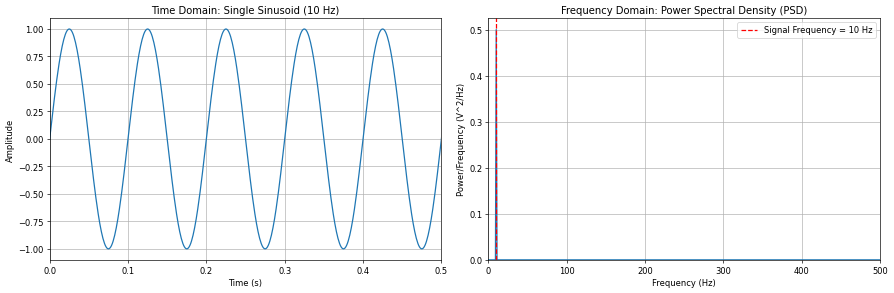

In [ ]:
from scipy.signal import periodogram

# Parameters for the sinusoid
Fs = 1000       # Sampling frequency (samples per second)
T = 1/Fs        # Sampling period
L = 1000        # Length of signal
t = np.arange(0, L) * T # Time vector
f_signal = 10   # Frequency of the sine wave (Hz)
Amplitude = 1

# Generate a single sinusoid
x = Amplitude * np.sin(2 * np.pi * f_signal * t)

# Compute the Power Spectral Density (PSD) using periodogram
# fs is the sampling frequency, scaling='density' returns PSD
f_spectrum, Pxx_den = periodogram(x, Fs, scaling='density')

# Plot the time domain signal
# Plot the frequency domain spectrum (PSD)

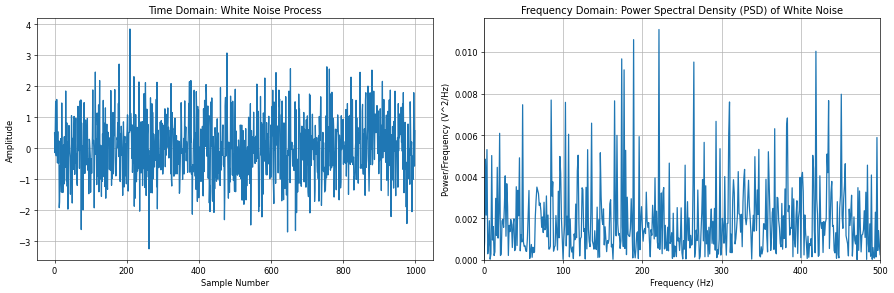

In [ ]:
from scipy.signal import periodogram

# Parameters for white noise generation
Fs = 1000       # Sampling frequency (samples per second)
L = 1000        # Length of signal
variance = 1    # Variance of the white noisef

# Generate white noise
np.random.seed(42) # for reproducibility
white_noise_data = np.random.normal(0, np.sqrt(variance), L)

# Compute the Power Spectral Density (PSD) using periodogram
f_spectrum_wn, Pxx_den_wn = periodogram(white_noise_data, Fs, scaling='density')

Time Domain: The left plot shows the white noise fluctuating randomly around zero, with no apparent pattern or correlation over time.

Frequency Domain (PSD): The right plot displays the PSD that is approximately flat across all frequencies. This indicates that all frequencies are present with roughly equal power, which is the defining characteristic of white noise.

##### Filtered Stationary Signal: Stationarity

A fundamental property in time series analysis and signal processing is how stationarity is affected when a stationary signal is passed through a filter.

**The Effect of LTI Filters** on Stationary Signals:
If a WSS process $X_t$ is passed through a LTI filter, the output process $Y_t$ will also be WSS.

The filter's output is a linear combination of its inputs.
The filter's characteristics do not change over time. If the input is shifted in time, the output is shifted by the same amount, and its shape remains the same.

**Mathematical Intuition:**
Let $X_t$ be a WSS process with mean $E[X_t] = \mu_X$ and autocorrelation $R_X(\tau)$.
An LTI filter can be represented by its impulse response $h[k]$ for discrete time. The output $Y_t$ is given by the convolution of the input $X_t$ and the filter's impulse response
$Y_t = \sum_{k=-\infty}^{\infty} h[k] X_{t-k}$.

For the output $Y_t$ to be WSS, it must satisfy the two conditions:
- The mean of $Y_t$ is constant.
$E[Y_t] = E\left[\sum_{k} h[k] X_{t-k}\right] = \sum_{k} h[k] E[X_{t-k}] = \sum_{k} h[k] \mu_X = \mu_X \sum_{k} h[k] = \mu_Y$.
Since $\mu_X$ is constant and $\sum_{k} h[k]$ a constant, assuming the filter is stable, $\mu_Y$ is also a constant.

- The autocorrelation function of $Y_t$ depends only on the lag $\tau$.
The autocorrelation of the output $R_Y(\tau)$ can be shown to be
$R_Y(\tau) = \sum_{i} \sum_{j} h[i] h[j] R_X(\tau - i + j)$.
This expression for $R_Y(\tau)$ only depends on the lag $\tau$, not on the absolute time $t$. Therefore, the output process $Y_t$ is also WSS.

Practical Implications:
This property is extremely important in signal processing and time series analysis. It means that if you have a stationary signal (e.g., a white noise process, which is WSS) and you process it with an LTI system (like a moving average filter, an autoregressive filter, etc.), the resulting signal will still be stationary. This allows us to build complex stationary models (like ARMA models) from simpler stationary components (like white noise inputs filtered through linear systems).

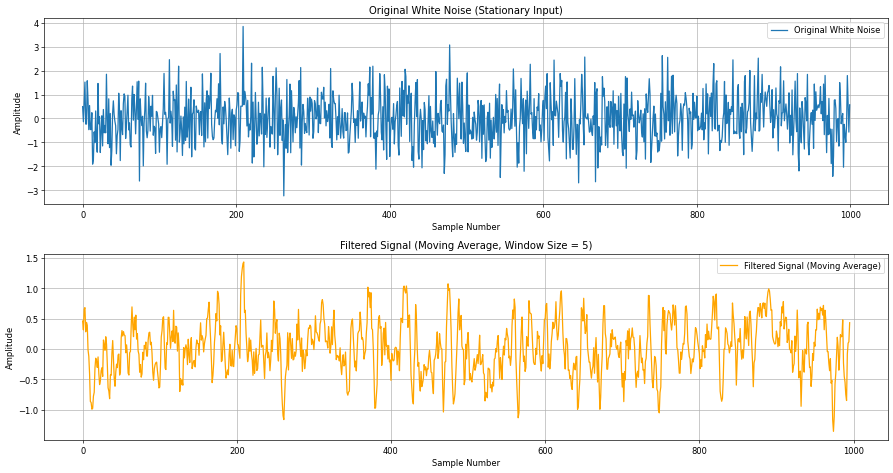

In [ ]:
# Assuming 'white_noise_data' is already generated from previous steps
# If not, generate it again:
# Fs = 1000 ; L = 1000 ; variance = 1 ; np.random.seed(42)
# white_noise_data = np.random.normal(0, np.sqrt(variance), L)

# Define a simple Moving Average (MA) filter
# This is a Linear Time-Invariant (LTI) filter
window_size = 5 # For a 5-point moving average
ma_filter = np.ones(window_size) / window_size

# Apply the filter to the white noise data
# np.convolve performs convolution, which is how LTI filters process signals
# 'valid' mode means only points where the convolution window fully overlaps are returned
filtered_signal = np.convolve(white_noise_data, ma_filter, mode='valid')

##### Explanation of the Filtering Example:

1.  **Input Signal**: Start with white noise data. It has a constant mean, close to zero, and constant variance, and no autocorrelation except at lag 0.
2.  **LTI Filter**: Define a simple MA filter, that is inherently LTI.
3.  **Filtering**: The np.convolve function applies the MA filter to the white noise. Convolution is the mathematical operation that describes how an LTI system transforms an input signal.
4.  **Output Signal:** This is the filtered_signal that is the result. It appears smoother than the original white noise. This is because the moving average reduces high-frequency fluctuations.
5.  **Stationarity Preservation**: Although the filtered_signal looks different, it remains WSS. It will still have a constant mean, the mean of the white noise, which is zero, passed through the filter, and a constant variance, and its autocorrelation will depend only on the lag. The filter changes the characteristics like variance and autocorrelation structure of the signal, but it does not introduce trends or changing volatility that would make it non-stationary.

##### Moving Average (MA) Model

MA is a time series model that models the output variable as a linear combination of past error terms. It is used to describe a stationary stochastic process.


An MA(q) process (MA of order q) is defined as
$X_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q}$,
where $X_t$ is the value of the time series at time $t$, $\mu$ is the mean of the series, $\epsilon_t$ is the white noise error term at time $t$, with zero mean and constant variance $\sigma^2_{\epsilon}$.

This represents the random shock or innovation at time $t$.
- $\theta_1, \theta_2, \dots, \theta_q$ are the coefficients of the moving average model, representing the impact of past error terms.
- $q$ is the order of the model, indicating the number of past error terms that influence the current value of the series.




##### Characteristics of an MA(q) Process:

*   **Stationarity**: MA models are inherently stationary, as they are linear combinations of a stationary white noise process. Their mean, variance, and autocorrelation structure are constant over time.
*   **Autocorrelation Function**: The most distinctive characteristic of an MA(q) process is that its ACF cuts off after lag q. This means that the correlation between $X_t$ and $X_{t-k}$ is zero for $k > q$. This property is crucial for identifying the order of an MA model.
*   **Finite Memory**: Unlike AR models which can have infinite memory (as seen when expressed as an infinite MA process), an MA(q) process only remembers the last $q$ error terms directly.

MA models are particularly useful for modeling time series data where sudden shocks or innovations have a direct, but limited, impact on the current and near-future values of the series.

First 10 values of MA(2) Process:
[ 0.7137442   1.87016369  0.8739711   0.08227998  1.36848463  1.64472133
  0.4647503   0.49110583 -0.27872398 -0.58101236]


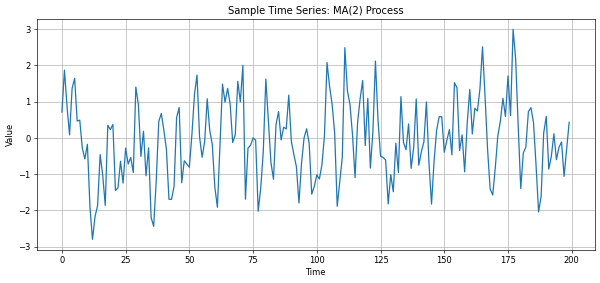

In [ ]:
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Function to generate an MA(q) process
def generate_ma_process(num_samples, mu, theta_coeffs, std_dev_epsilon):
    q = len(theta_coeffs)
    epsilon = np.random.normal(0, std_dev_epsilon, num_samples + q) # Generate extra epsilon for lags
    ma_process = np.zeros(num_samples)

    for t in range(num_samples):
        current_val = mu + epsilon[t+q] # Current white noise term
        for i in range(q):
            current_val += theta_coeffs[i] * epsilon[t + q - (i+1)]
        ma_process[t] = current_val
    return ma_process

# Parameters for MA(2) model
num_samples = 200
mu_ma = 0.0 # Mean of the MA process
theta_coeffs_ma2 = [0.6, 0.3] # theta_1 = 0.6, theta_2 = 0.3
std_dev_epsilon_ma = 1.0 # Standard deviation of white noise errors

# Generate a sample time series using an MA(2) model
np.random.seed(42) # for reproducibility
ma2_data = generate_ma_process(num_samples, mu_ma, theta_coeffs_ma2, std_dev_epsilon_ma)

<Figure size 720x300 with 0 Axes>

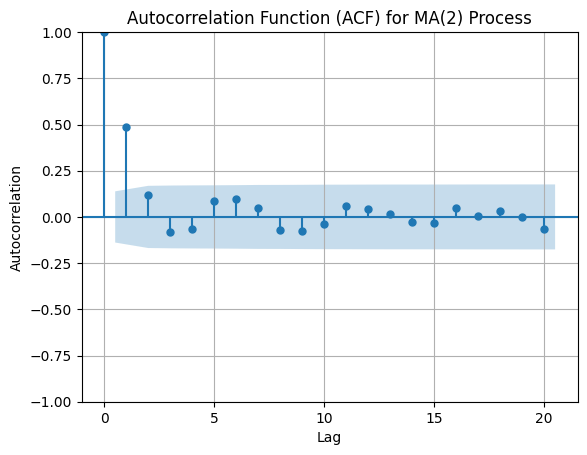

In [ ]:
# Identify the order of an MA model using ACF. Compute and plot the ACF

##### MA(2) Generation and Order Identification:

1.  **MA(q) Process Generation**: The generate_ma_process function creates a Moving Average process of order $q$. The current value of the series is a linear combination of the current and past $q$ white noise error terms.

2.  **Sample MA(2) Time Series**: We generated an MA(2) series with $theta_1 = 0.6$ and $theta_2 = 0$.3`. The plot shows a stationary series fluctuating around its mean (which is 0 in this case).

3.  **ACF for Order Identification**: ACF plot is crucial for identifying the order of an MA model. For an MA(q) process, the theoretical ACF 'cuts off' after lag $q$. This means that the autocorrelations at lags greater than $q$ are theoretically zero. In our generated MA(2) process:
    *   Observe statistically significant autocorrelations (outside the blue shaded confidence interval) at **Lag 1** and **Lag 2**.
    *   For lags greater than 2 (i.e., Lag 3, Lag 4, and so on), the autocorrelations are generally within the confidence interval, indicating they are not statistically significant.

    This clear cutoff after Lag 2 strongly suggests that the underlying model is an MA(2) process, correctly identifying the order $q = 2$.

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  190
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -257.857
Date:                Mon, 16 Mar 2026   AIC                            523.713
Time:                        19:17:47   BIC                            536.701
Sample:                             0   HQIC                           528.974
                                - 190                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0617      0.124     -0.497      0.619      -0.305       0.182
ma.L1          0.5443      0.081      6.680      0.000       0.385       0.704
ma.L2          0.2681      0.082      3.280      0.0

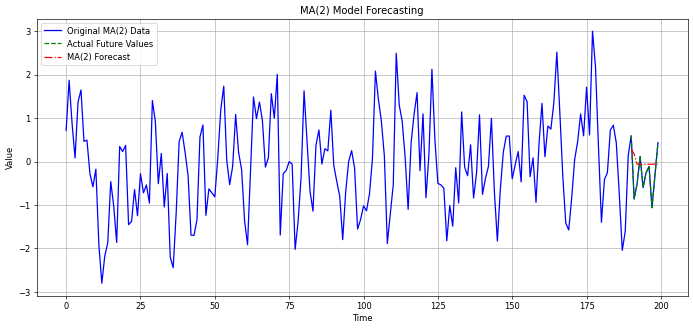

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Assuming ma2_data is already available from previous steps

# Split data into training and testing sets (or use all data for fitting and forecast out-of-sample)
train_data = ma2_data[:-10]  # Use most of the data for training

# Fit an MA(2) model to the data
# The order (p,d,q) for an MA(2) model is (0,0,2)
# Here, 'p' is for AR, 'd' for differencing, 'q' for MA
model = ARIMA(train_data, order=(0, 0, 2))
model_fit = model.fit()

# Print the model summary to see coefficients and other stats
print(model_fit.summary())

# Generate forecasts
# forecast_steps = 10 (forecast for the next 10 steps)
forecast_steps = 10
forecast_result = model_fit.forecast(steps=forecast_steps)

# Prepare actual values for comparison if available
actual_values = ma2_data[-forecast_steps:]

##### MA(2) Forecasting:

1.  **Model Fitting**: We use the $ARIMA$ model from $statsmodels.tsa.arima.model$. For MA(q) model, the $order$ parameter is set as $(0, 0, q)$, for MA(2) it's $(0, 0, 2)$. The $fit()$ method estimates the model parameters.
2.  **Forecasting**: The forecast(steps=$n$) method is used to predict $n$ steps into the future. It provides point forecasts.
3.  The plot shows the original MA(2) data, the actual future values (if available), and the forecasts generated by the fitted MA(2) model. For MA models, forecasts tend to revert to the mean quickly, especially after the $q$ lags.

#### Autoregressive Integrated Moving Average (ARIMA) Model

The **ARIMA** model is generalization of the ARMA model. It is one of the most popular and powerful models for time series forecasting. ARIMA models are applied to time series data that show evidence of non-stationarity, where an initial differencing step, corresponding to the integrated part of the model, can be applied to remove the non-stationarity.

An ARIMA model is typically specified by three parameters: $p$, $d$, and $q$.

*   **AR(p)**: Autoregressive (p) refers to the number of autoregressive terms. This is the order of the AR part of the model, indicating that the dependent variable's current value is related to its own past values.
*   **I(d)**: Integrated (d) refers to the number of nonseasonal differences needed for stationarity. Differencing involves computing the difference between consecutive observations. It's used to stabilize the mean of a time series by removing trends.
*   **MA(q)**: Moving Average (q) refers to the number of moving average terms. This is the order of the MA part of the model, indicating that the dependent variable's current value is related to past forecast errors.

The notation for an ARIMA model is $ARIMA(p, d, q)$.



##### General Form (simplified):

A non-seasonal ARIMA(p, d, q) model is written as
$(1 - \phi_1 B - \dots - \phi_p B^p)(1 - B)^d X_t = (1 + \theta_1 B + \dots + \theta_q B^q) \epsilon_t$,
where $X_t$ is the time series, $B$ is the backshift operator ($B X_t = X_{t-1}$). B also known as Lag operator, and $\phi_i$ are the autoregressive parameters, $\theta_i$ are the moving average parameters, $\epsilon_t$ is white noise, and $(1 - B)^d$ represents the differencing component.

In essence, ARIMA models combine the concepts of autoregression (AR), differencing (I), and moving averages (MA) to create a flexible framework for modeling a wide range of time series data. We'll delve into the specifics of identifying $p$, $d$, and $q$ and fitting these models in more detail later.

Identifying the appropriate orders for the ARIMA model (p, d, q) is a critical step, often involving a combination of statistical tests and visual analysis of autocorrelation plots. Here's how each parameter is typically determined:

##### Determining $d$ - Differencing Order for Integration

The parameter $d$ represents the number of nonseasonal differences required to make the time series stationary. A stationary series has a constant mean, variance, and autocorrelation structure over time. Non-stationary series, particularly those with trends or seasonality, need to be differenced.

**How to identify $d$**:
-   Plot the time series. If there's an obvious trend, increasing or decreasing mean over time, differencing is likely needed. If there's clear seasonality, seasonal differencing might be required.
-   Use formal statistical tests for stationarity like the Augmented Dickey-Fuller (**ADF**) test or the Kwiatkowski-Phillips-Schmidt-Shin (**KPSS**) test.
If the series is non-stationary, difference it once and re-run the test.
Repeat until the series becomes stationary. The number of differences applied is your $d$ value.
**Common $d$ values**: $d=0$ - Series is already stationary; $d=1$ - Series has a linear trend; $d=2$ - Series has a quadratic trend less common.



##### Determining $p$ - Order of the Autoregressive (AR) part

The parameter $p$ represents the number of lag observations included in the model (i.e., the order of the AR part). It reflects how many past observations influence the current observation.

**How to identify $p$**:
- PACF plot measures the correlation between an observation and a lag observation that is not explained by the correlations at intermediate lags.
- For an AR(p) model, the theoretical PACF cuts off after lag $p$. This means that the PACF will show significant spikes at lags 1, 2, ..., $p$, and then rapidly drop to non-significant levels within the confidence intervals for lags greater than $p$.
- Therefore, look for the lag after which the PACF plot drops to zero or near-zero, this lag is $p$ value.

##### Determining $q$ - Order of the Moving Average (MA) part

The parameter $q$ represents the number of lagged forecast errors, white noise error terms, included in the model (i.e., the order of the MA part). It indicates how many past error terms influence the current observation.

**How to identify $q$**:
*   ACF plot measures the correlation between an observation and a lag observation.
*   For an MA(q) model, the theoretical ACF cuts off after lag $q$. This means that the ACF will show significant spikes at lags 1, 2, ..., $q$, and then rapidly drop to non-significant levels within the confidence intervals for lags greater than $q$. Therefore, look for the lag after which the ACF plot drops to zero or near-zero, this lag is $q$ value.
